# PRT565 Assessment 02 – Rain in Australia Classification

| Field | Details |
|---|---|
| **Name** | Thi Xuan Thanh Tran |
| **Student ID** | S389244 |
| **Dataset** | Rain in Australia (weatherAUS) |
| **Unit** | PRT565 - Machine Learning, Artificial Intelligence and Algorithms |


---
## 1. Import Libraries

In [1]:
# Standard data manipulation and numerical computing
import pandas as pd
import numpy as np
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Save figures into one folder (cleared each time this cell runs)
FIG_DIR = Path('FFigures')
FIG_DIR.mkdir(exist_ok=True)
for _old in FIG_DIR.glob('*.png'):
    try:
        _old.unlink()
    except PermissionError:
        pass  # locked by Explorer/OneDrive/preview

_orig_show = plt.show
_fig_counter = {'n': 0}

def _show_and_save(*args, **kwargs):
    _fig_counter['n'] += 1
    out = FIG_DIR / f'fig_{_fig_counter["n"]:02d}.png'
    plt.gcf().savefig(out, dpi=120, bbox_inches='tight')
    _orig_show(*args, **kwargs)

plt.show = _show_and_save

# Preprocessing
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score
)

# Suppress minor warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Fix random seed for reproducibility
RANDOM_STATE = 42

print('All libraries imported successfully.')
print(f'Figures folder reset -> {FIG_DIR.resolve()}')

All libraries imported successfully.
Figures folder reset -> C:\Users\xuant\OneDrive\Máy tính\S2 2026\PRT565 ML\Assignment 2\FFigures


---
## 2. Load Dataset

In [2]:
# Load the dataset from the local CSV file
df = pd.read_csv('weatherAUS.csv')

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded successfully.
Shape: 145,460 rows × 23 columns


---
## 3. Exploratory Data Analysis

### 3.1 Dataset Overview

In [3]:
# Preview the first few rows to understand the data structure
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
# Display column names, non-null counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

### 3.2 Descriptive Statistics

In [5]:
# Summary statistics for numerical features
# This helps identify potential outliers and understand feature distributions
df.describe().round(2)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.00,144199.00,142199.00,82670.00,75625.00,135197.00,143693.00,142398.00,142806.00,140953.00,130395.00,130432.00,89572.00,86102.00,143693.00,141851.00
mean,12.19,23.22,2.36,5.47,7.61,40.04,14.04,18.66,68.88,51.54,1017.65,1015.26,4.45,4.51,16.99,21.68
std,6.40,7.12,8.48,4.19,3.79,13.61,8.92,8.81,19.03,20.80,7.11,7.04,2.89,2.72,6.49,6.94
min,-8.50,-4.80,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,980.50,977.10,0.00,0.00,-7.20,-5.40
25%,7.60,17.90,0.00,2.60,4.80,31.00,7.00,13.00,57.00,37.00,1012.90,1010.40,1.00,2.00,12.30,16.60
50%,12.00,22.60,0.00,4.80,8.40,39.00,13.00,19.00,70.00,52.00,1017.60,1015.20,5.00,5.00,16.70,21.10
75%,16.90,28.20,0.80,7.40,10.60,48.00,19.00,24.00,83.00,66.00,1022.40,1020.00,7.00,7.00,21.60,26.40
max,33.90,48.10,371.00,145.00,14.50,135.00,130.00,87.00,100.00,100.00,1041.00,1039.60,9.00,9.00,40.20,46.70


### 3.3 Missing Values

In [6]:
# Calculate the count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)
print(missing_df)

               Missing Count  Missing (%)
Sunshine               69835        48.01
Evaporation            62790        43.17
Cloud3pm               59358        40.81
Cloud9am               55888        38.42
Pressure9am            15065        10.36
Pressure3pm            15028        10.33
WindDir9am             10566         7.26
WindGustDir            10326         7.10
WindGustSpeed          10263         7.06
Humidity3pm             4507         3.10
WindDir3pm              4228         2.91
Temp3pm                 3609         2.48
RainTomorrow            3267         2.25
Rainfall                3261         2.24
RainToday               3261         2.24
WindSpeed3pm            3062         2.11
Humidity9am             2654         1.82
Temp9am                 1767         1.21
WindSpeed9am            1767         1.21
MinTemp                 1485         1.02
MaxTemp                 1261         0.87


### 3.4 Duplicate Records

In [7]:
# Check for exact duplicate rows in the dataset
n_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {n_duplicates}')

Number of duplicate rows: 0


### 3.5 Target Variable Distribution

Target class distribution:
               Count  Percentage (%)
RainTomorrow                        
No            110316            77.6
Yes            31877            22.4


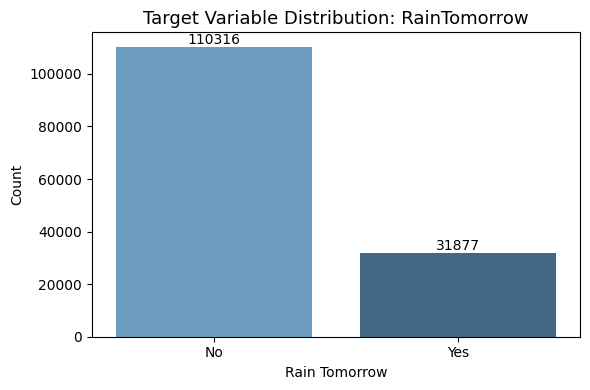

In [8]:
# Examine the balance of the target classes
target_counts = df['RainTomorrow'].value_counts()
target_pct = df['RainTomorrow'].value_counts(normalize=True) * 100
print('Target class distribution:')
print(pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(1)}))

# Visualise the class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='RainTomorrow', palette='Blues_d', order=['No', 'Yes'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.title('Target Variable Distribution: RainTomorrow', fontsize=13)
plt.xlabel('Rain Tomorrow')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Target is imbalanced: ~78% No, ~22% Yes → use class_weight='balanced' and report F1-score alongside accuracy


### 3.6 Feature Analysis

In [9]:
# Separate numerical and categorical features for targeted analysis
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

print(f'Numerical features ({len(numerical_features)}): {numerical_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numerical features (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Categorical features (4): ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


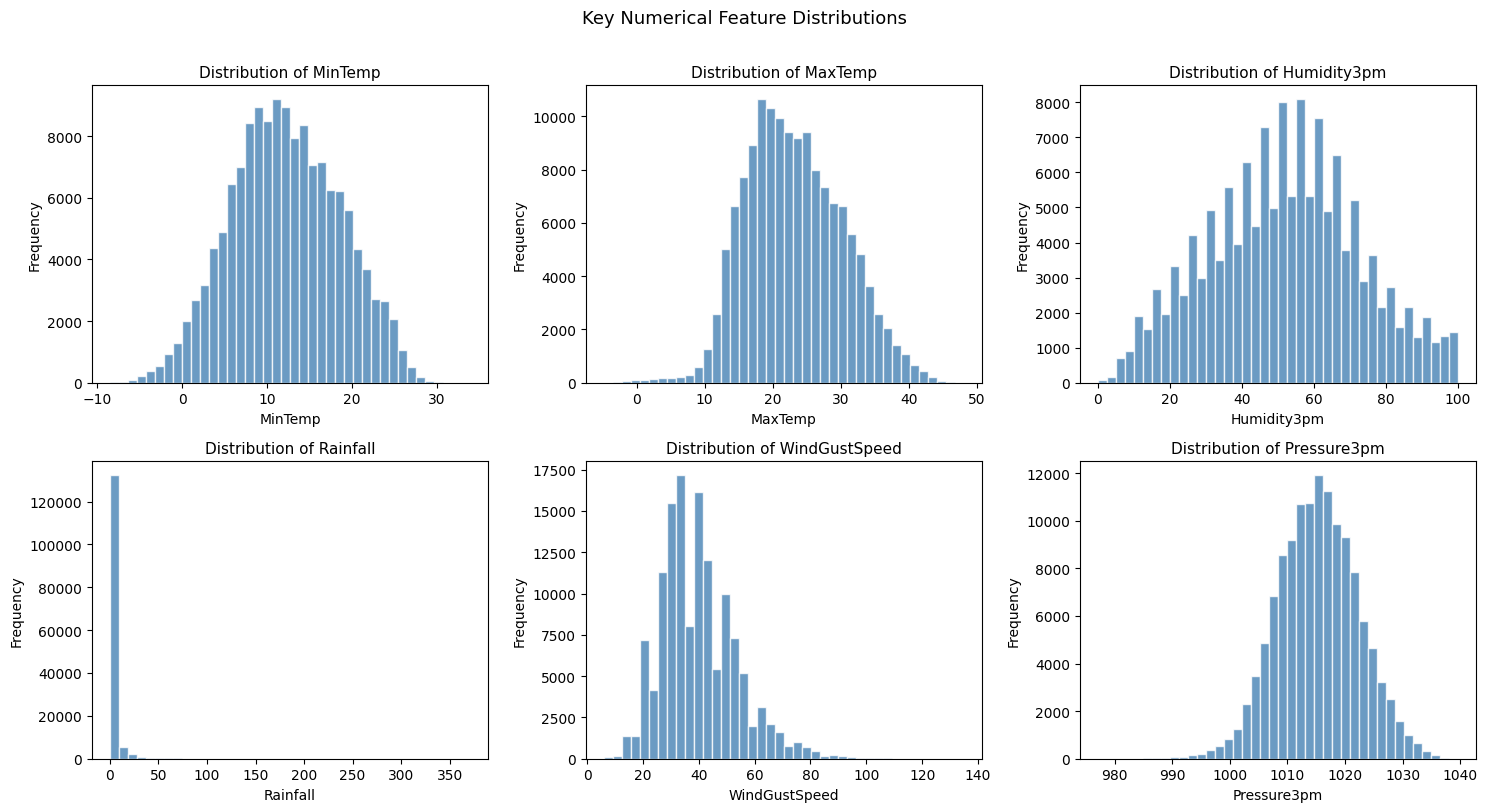

In [10]:
# Distribution of key numerical features
key_num_features = ['MinTemp', 'MaxTemp', 'Humidity3pm', 'Rainfall', 'WindGustSpeed', 'Pressure3pm']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_num_features):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Key Numerical Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

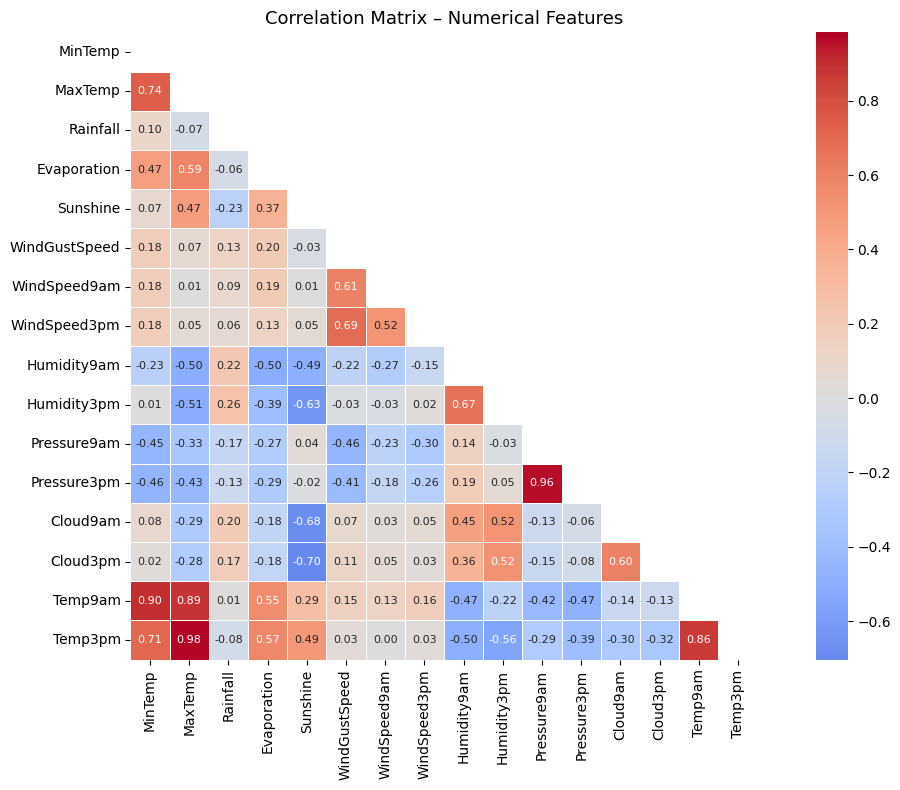

In [11]:
# Correlation matrix of numerical features to identify multicollinearity
plt.figure(figsize=(12, 8))
corr = df[numerical_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix – Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# Compute correlation of each numerical feature with the target (encode RainTomorrow as 0/1)
corr_with_target = df.copy()
corr_with_target['RainTomorrow'] = corr_with_target['RainTomorrow'].map({'No': 0, 'Yes': 1})
corr_with_target = corr_with_target[numerical_features + ['RainTomorrow']].corr()['RainTomorrow'].drop('RainTomorrow').abs().sort_values(ascending=False)
print(corr_with_target)

Sunshine         0.450768
Humidity3pm      0.446160
Cloud3pm         0.381870
Cloud9am         0.317380
Humidity9am      0.257161
Pressure9am      0.246371
Rainfall         0.239032
WindGustSpeed    0.234010
Pressure3pm      0.226031
Temp3pm          0.192424
MaxTemp          0.159237
Evaporation      0.119285
WindSpeed9am     0.090995
WindSpeed3pm     0.087817
MinTemp          0.083936
Temp9am          0.025691
Name: RainTomorrow, dtype: float64


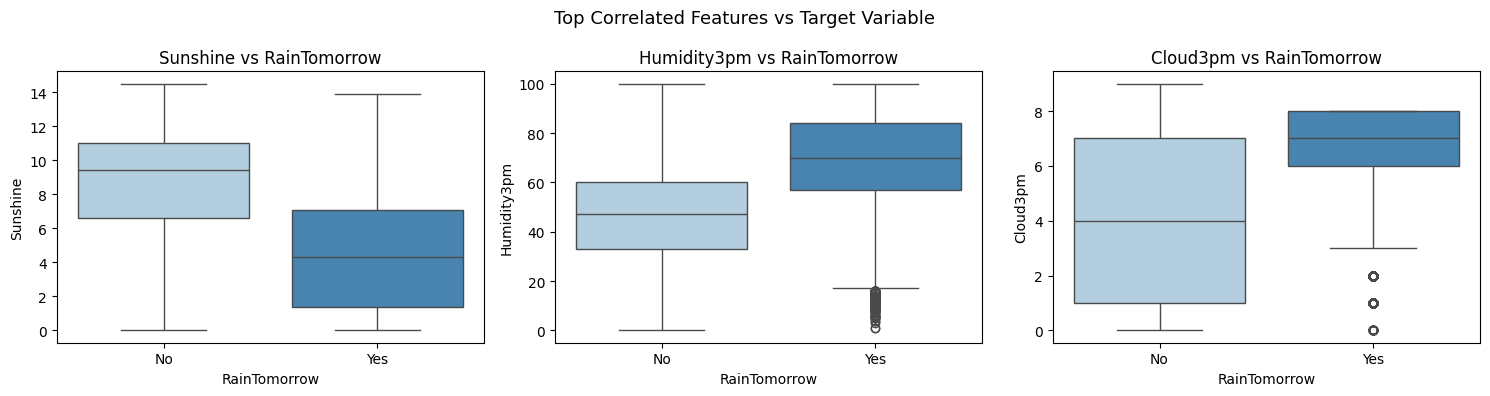

In [13]:
# Top features correlated with RainTomorrow: Sunshine, Humidity3pm, Cloud3pm
# visualise their distributions split by RainTomorrow
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='RainTomorrow', y='Sunshine',
            palette='Blues', order=['No', 'Yes'], ax=axes[0])
axes[0].set_title('Sunshine vs RainTomorrow')

sns.boxplot(data=df, x='RainTomorrow', y='Humidity3pm',
            palette='Blues', order=['No', 'Yes'], ax=axes[1])
axes[1].set_title('Humidity3pm vs RainTomorrow')

sns.boxplot(data=df, x='RainTomorrow', y='Cloud3pm',
            palette='Blues', order=['No', 'Yes'], ax=axes[2])
axes[2].set_title('Cloud3pm vs RainTomorrow')

plt.suptitle('Top Correlated Features vs Target Variable', fontsize=13)
plt.tight_layout()
plt.show()

### 3.7 Temporal Patterns (Month / Season)
# Rainfall risk often varies by season in Australia — engineer Month before modelling


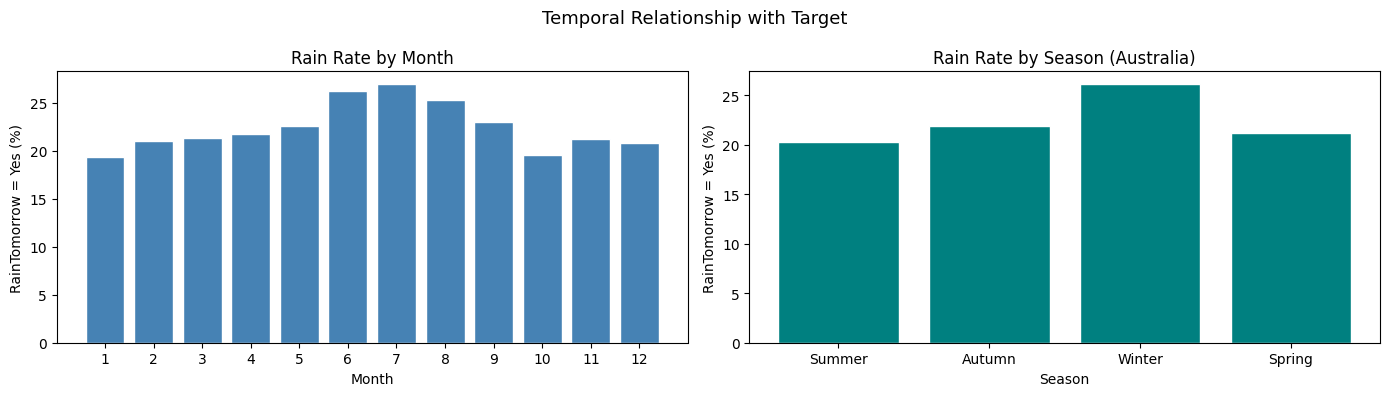

Rain rate by month (%):
Month
1     19.33
2     20.97
3     21.33
4     21.78
5     22.53
6     26.18
7     26.92
8     25.25
9     22.97
10    19.57
11    21.25
12    20.81

Rain rate by season (%):
Season
Summer    20.30
Autumn    21.89
Winter    26.12
Spring    21.24


In [14]:
# Derive Month and Season on a temporary copy for EDA (full dataset)
df_eda = df.dropna(subset=['RainTomorrow', 'Date']).copy()
df_eda['Date'] = pd.to_datetime(df_eda['Date'])
df_eda['Month'] = df_eda['Date'].dt.month
df_eda['Season'] = df_eda['Month'].map(
    lambda m: (
        'Summer' if m in (12, 1, 2) else
        'Autumn' if m in (3, 4, 5) else
        'Winter' if m in (6, 7, 8) else
        'Spring'
    )
)

# Rain rate (%) by month
month_rain = (
    df_eda.assign(rain_flag=df_eda['RainTomorrow'].map({'No': 0, 'Yes': 1}))
    .groupby('Month')['rain_flag']
    .mean()
    * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(month_rain.index, month_rain.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel('Month')
axes[0].set_ylabel('RainTomorrow = Yes (%)')
axes[0].set_title('Rain Rate by Month')

season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
season_rain = (
    df_eda.assign(rain_flag=df_eda['RainTomorrow'].map({'No': 0, 'Yes': 1}))
    .groupby('Season')['rain_flag']
    .mean()
    .reindex(season_order)
    * 100
)
axes[1].bar(season_rain.index, season_rain.values, color='teal', edgecolor='white')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('RainTomorrow = Yes (%)')
axes[1].set_title('Rain Rate by Season (Australia)')

plt.suptitle('Temporal Relationship with Target', fontsize=13)
plt.tight_layout()
plt.show()

print('Rain rate by month (%):')
print(month_rain.round(2).to_string())
print()
print('Rain rate by season (%):')
print(season_rain.round(2).to_string())

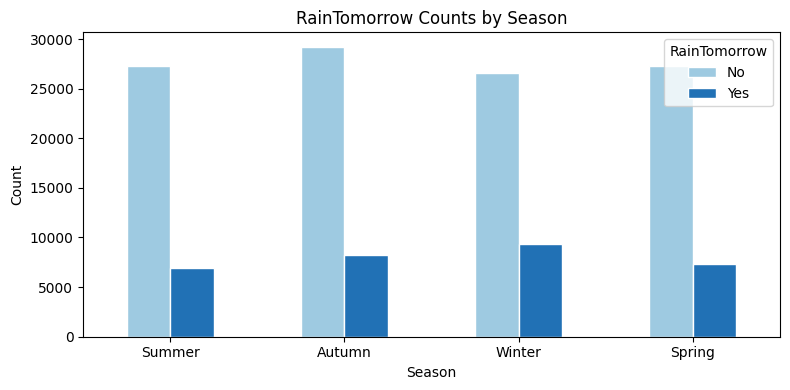

RainTomorrow     No   Yes
Season                   
Summer        27301  6955
Autumn        29212  8185
Winter        26545  9385
Spring        27258  7352


In [15]:
# Count of RainTomorrow by Season (absolute counts)
fig, ax = plt.subplots(figsize=(8, 4))
season_ct = pd.crosstab(df_eda['Season'], df_eda['RainTomorrow']).reindex(season_order)
season_ct.plot(kind='bar', ax=ax, color=['#9ecae1', '#2171b5'], edgecolor='white')
ax.set_title('RainTomorrow Counts by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Count')
ax.legend(title='RainTomorrow')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(season_ct)

---
## 4. Data Preprocessing

### 4.1 Feature Engineering and Target Separation
# Extract Month / Season / cyclical encodings from Date, then drop Date and Location


In [16]:
# Drop rows where the target variable is missing
df_clean = df.dropna(subset=['RainTomorrow']).copy()

# --- Feature engineering from Date (before dropping it) ---
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Month'] = df_clean['Date'].dt.month

# Cyclical encoding so December (12) is close to January (1)
df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)

# Australian seasons (Southern Hemisphere)
def month_to_season(month):
    if month in (12, 1, 2):
        return 'Summer'
    if month in (3, 4, 5):
        return 'Autumn'
    if month in (6, 7, 8):
        return 'Winter'
    return 'Spring'

df_clean['Season'] = df_clean['Month'].map(month_to_season)

print('Engineered features:')
print(df_clean[['Date', 'Month', 'Month_sin', 'Month_cos', 'Season']].head(8))
print()
print('Season distribution:')
print(df_clean['Season'].value_counts())

# Drop Date and Location — Date raw string is replaced by Month/Season encodings;
# Location adds 49 categories that would inflate dimensionality
COLS_TO_DROP = ['Date', 'Location']

X = df_clean.drop(columns=COLS_TO_DROP + ['RainTomorrow'])
y = df_clean['RainTomorrow']

print()
print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape:  {y.shape}')
print(f'Target classes: {y.unique()}')
print(f'Columns: {list(X.columns)}')

Engineered features:
        Date  Month     Month_sin  Month_cos  Season
0 2008-12-01     12 -2.449294e-16        1.0  Summer
1 2008-12-02     12 -2.449294e-16        1.0  Summer
2 2008-12-03     12 -2.449294e-16        1.0  Summer
3 2008-12-04     12 -2.449294e-16        1.0  Summer
4 2008-12-05     12 -2.449294e-16        1.0  Summer
5 2008-12-06     12 -2.449294e-16        1.0  Summer
6 2008-12-07     12 -2.449294e-16        1.0  Summer
7 2008-12-08     12 -2.449294e-16        1.0  Summer

Season distribution:
Season
Autumn    37397
Winter    35930
Spring    34610
Summer    34256
Name: count, dtype: int64

Feature matrix shape: (142193, 24)
Target vector shape:  (142193,)
Target classes: ['No' 'Yes']
Columns: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'Mon

### 4.2 Identify Feature Types for Preprocessing Pipeline

In [17]:
# Identify numerical and categorical columns in the feature set
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical columns ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numerical columns (18): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Month_sin', 'Month_cos']
Categorical columns (5): ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season']


### 4.3 Encode Target Variable

In [18]:
# Encode the target variable: 'No' → 0, 'Yes' → 1
y = y.map({'No': 0, 'Yes': 1})
print('Target encoding:')
print(y.value_counts())

Target encoding:
RainTomorrow
0    110316
1     31877
Name: count, dtype: int64


### 4.4 Train-Test Split
# 80/20 stratified split - fit preprocessors on train only to prevent data leakage


In [19]:
# Split the data before fitting any preprocessors to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y   # preserve class balance in both splits
)

print(f'Training set:  {X_train.shape[0]:,} samples')
print(f'Test set:      {X_test.shape[0]:,} samples')
print(f'Train class distribution:\n{y_train.value_counts(normalize=True).round(3)}')

Training set:  113,754 samples
Test set:      28,439 samples
Train class distribution:
RainTomorrow
0    0.776
1    0.224
Name: proportion, dtype: float64


### 4.5 Preprocessing Pipeline
# Numerical: median imputation + StandardScaler
# Categorical: most_frequent imputation + OneHotEncoder(handle_unknown= 'ignore')


In [20]:
# Numerical pipeline: impute median -> scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute most_frequent -> one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

# Fit on training data only, then transform both train and test sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'Processed training set shape: {X_train_processed.shape}')
print(f'Processed test set shape:     {X_test_processed.shape}')

Processed training set shape: (113754, 72)
Processed test set shape:     (28439, 72)


---
## 5. Logistic Regression

### 5.1 Model Training
# Linear classifier; max_iter=1000 for convergence; class_weight='balanced' for imbalance


In [21]:
# Initialise and train the Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # compensate for class imbalance
    random_state=RANDOM_STATE
)

lr_model.fit(X_train_processed, y_train)
print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


### 5.2 Predictions

In [22]:
# Generate predictions on the test set
lr_pred = lr_model.predict(X_test_processed)

### 5.3 Evaluation

In [23]:
# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f'Logistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)')
print()

# Full classification report: precision, recall, F1-score per class
print('Classification Report:')
print(classification_report(y_test, lr_pred, target_names=['No Rain', 'Rain']))

Logistic Regression Accuracy: 0.7918 (79.18%)

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.92      0.80      0.86     22064
        Rain       0.52      0.77      0.63      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.79      0.74     28439
weighted avg       0.83      0.79      0.80     28439



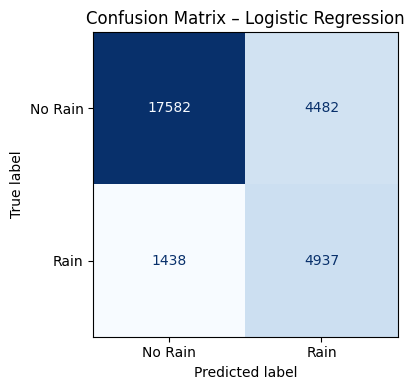

In [24]:
# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Rain', 'Rain'])
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – Logistic Regression', fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Decision Tree

### 6.1 Model Training
# Gini criterion; max_depth=8 + min_samples_leaf=50 to limit overfitting


In [25]:
# Initialise and train the Decision Tree classifier
dt_model = DecisionTreeClassifier(
    criterion='gini',         # Gini impurity as the splitting criterion
    max_depth=8,              # limit depth to control overfitting
    min_samples_leaf=50,      # each leaf must have at least 50 samples
    class_weight='balanced',
    random_state=RANDOM_STATE
)

dt_model.fit(X_train_processed, y_train)
print('Decision Tree model trained successfully.')
print(f'Tree depth: {dt_model.get_depth()}')
print(f'Number of leaves: {dt_model.get_n_leaves()}')

Decision Tree model trained successfully.
Tree depth: 8
Number of leaves: 211


### 6.2 Predictions

In [26]:
dt_pred = dt_model.predict(X_test_processed)

### 6.3 Evaluation

In [27]:
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f'Decision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, dt_pred, target_names=['No Rain', 'Rain']))

Decision Tree Accuracy: 0.7839 (78.39%)

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.92      0.79      0.85     22064
        Rain       0.51      0.75      0.61      6375

    accuracy                           0.78     28439
   macro avg       0.71      0.77      0.73     28439
weighted avg       0.83      0.78      0.80     28439



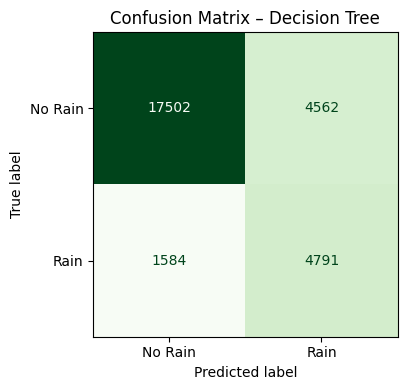

In [28]:
# Confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No Rain', 'Rain'])
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix – Decision Tree', fontsize=12)
plt.tight_layout()
plt.show()

### 6.4 Tree Visualisation

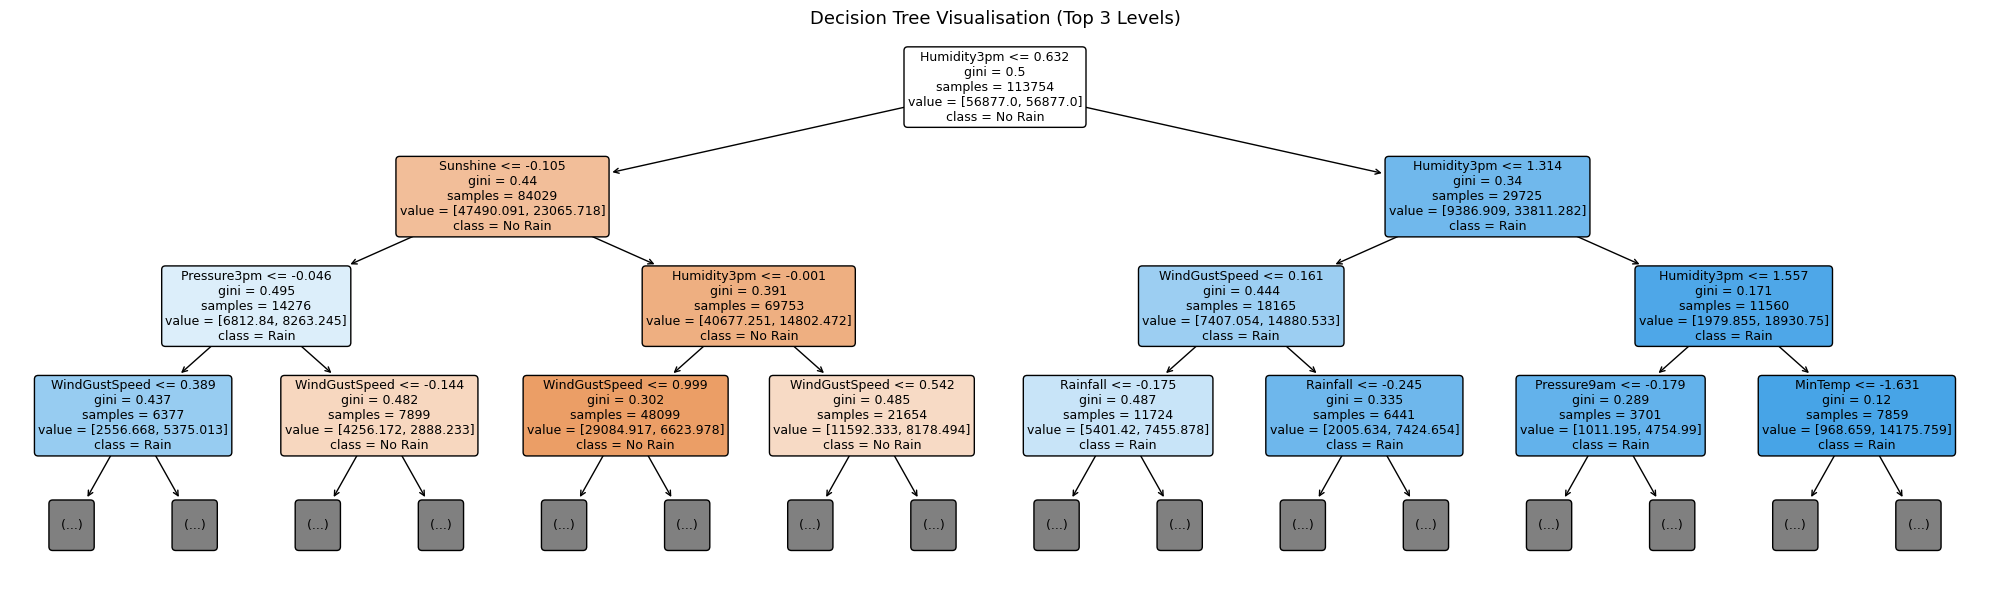

In [29]:
# Retrieve feature names after preprocessing (OHE creates new columns)
ohe_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + ohe_feature_names

# Visualise the top 3 levels of the decision tree for readability
plt.figure(figsize=(20, 6))
plot_tree(
    dt_model,
    max_depth=3,           # display only top 3 levels
    feature_names=all_feature_names,
    class_names=['No Rain', 'Rain'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree Visualisation (Top 3 Levels)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Random Forest

### 7.1 Model Training
# Ensemble of 100 trees; random feature subsets reduce variance vs single Decision Tree


In [30]:
# Initialise and train the Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,         # number of trees in the forest
    max_depth=10,             # limit individual tree depth
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1                 # use all available CPU cores
)

rf_model.fit(X_train_processed, y_train)
print('Random Forest model trained successfully.')

Random Forest model trained successfully.


### 7.2 Predictions

In [31]:
rf_pred = rf_model.predict(X_test_processed)

### 7.3 Evaluation

In [32]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f'Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, rf_pred, target_names=['No Rain', 'Rain']))

Random Forest Accuracy: 0.8005 (80.05%)

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.92      0.81      0.86     22064
        Rain       0.54      0.76      0.63      6375

    accuracy                           0.80     28439
   macro avg       0.73      0.79      0.75     28439
weighted avg       0.84      0.80      0.81     28439



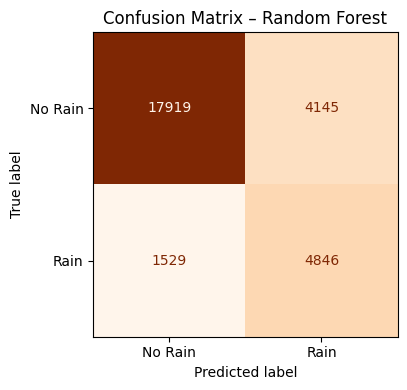

In [33]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Rain', 'Rain'])
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Confusion Matrix – Random Forest', fontsize=12)
plt.tight_layout()
plt.show()

### 7.4 Feature Importance

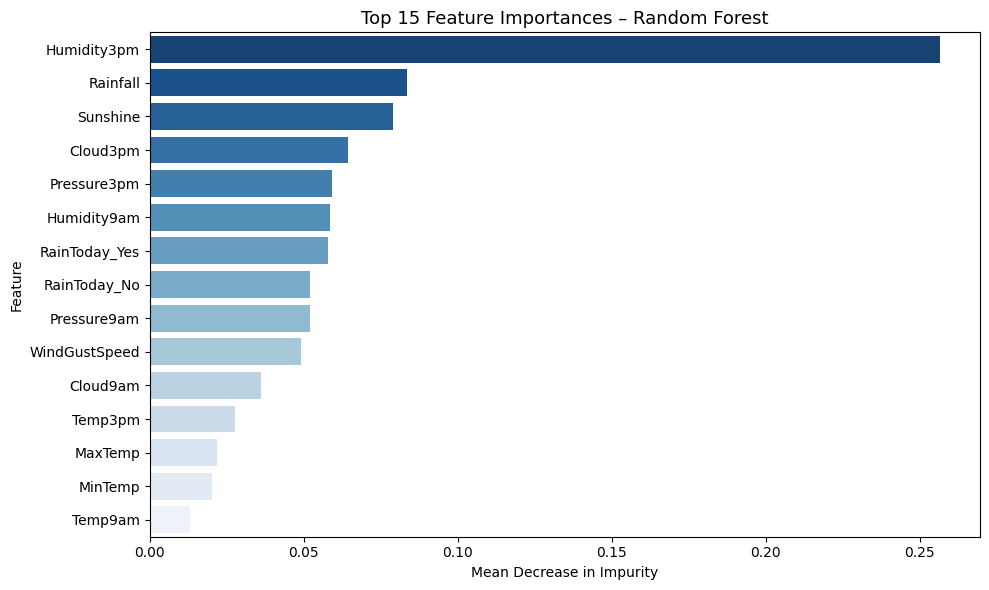

      Feature  Importance
  Humidity3pm    0.256703
     Rainfall    0.083326
     Sunshine    0.078779
     Cloud3pm    0.064166
  Pressure3pm    0.059126
  Humidity9am    0.058366
RainToday_Yes    0.057711
 RainToday_No    0.052109
  Pressure9am    0.051881
WindGustSpeed    0.048994
     Cloud9am    0.036101
      Temp3pm    0.027589
      MaxTemp    0.021628
      MinTemp    0.020270
      Temp9am    0.012896


In [34]:
# Extract and plot the top 15 most important features from the Random Forest
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 15 Feature Importances – Random Forest', fontsize=13)
plt.xlabel('Mean Decrease in Impurity')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

---
## 8. Gradient Boosting

### 8.1 Model Training
# Boosting ensemble; sample_weight balances class imbalance (no class_weight param)


In [35]:
# Initialise and train the Histogram Gradient Boosting classifier
hgb_model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.1,
    max_iter=100,
    random_state=RANDOM_STATE
)

# HistGradientBoosting has no class_weight — use balanced sample weights instead
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
hgb_model.fit(X_train_processed, y_train, sample_weight=sample_weights)
print('Gradient Boosting model trained successfully.')

Gradient Boosting model trained successfully.


### 8.2 Predictions


In [36]:
hgb_pred = hgb_model.predict(X_test_processed)

### 8.3 Evaluation


In [37]:
hgb_accuracy = accuracy_score(y_test, hgb_pred)
print(f'Gradient Boosting Accuracy: {hgb_accuracy:.4f} ({hgb_accuracy*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, hgb_pred, target_names=['No Rain', 'Rain']))

Gradient Boosting Accuracy: 0.8029 (80.29%)

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.93      0.81      0.86     22064
        Rain       0.54      0.79      0.64      6375

    accuracy                           0.80     28439
   macro avg       0.74      0.80      0.75     28439
weighted avg       0.84      0.80      0.81     28439



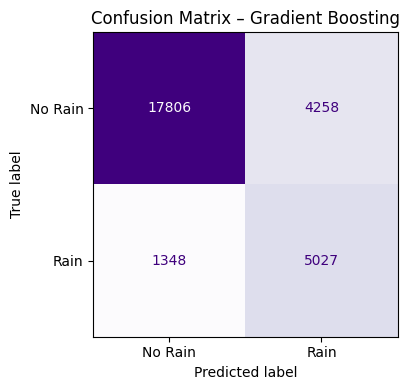

In [38]:
# Confusion matrix for Gradient Boosting
cm_hgb = confusion_matrix(y_test, hgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_hgb, display_labels=['No Rain', 'Rain'])
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Confusion Matrix – Gradient Boosting', fontsize=12)
plt.tight_layout()
plt.show()

---
## 9. Cross-Validation
# Nested-safe CV: each fold fits preprocessing only on that fold's training split (no leakage into val folds)


In [39]:
# Stratified K-Fold preserves class balance in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Build full pipelines: clone(preprocessor) + model
# CV runs on RAW X_train so imputation/encoding are refit inside each fold
cv_model_defs = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        criterion='gini', max_depth=8, min_samples_leaf=50,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': HistGradientBoostingClassifier(
        max_depth=6, learning_rate=0.1, max_iter=100, random_state=RANDOM_STATE
    ),
}

cv_rows = []
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

for name, model in cv_model_defs.items():
    pipe = Pipeline(steps=[
        ('preprocess', clone(preprocessor)),  # unfitted copy - critical for clean CV
        ('model', model),
    ])

    if name == 'Gradient Boosting':
        scores = cross_val_score(
            pipe, X_train, y_train,
            cv=cv, scoring='f1_macro', n_jobs=-1,
            fit_params={'model__sample_weight': sample_weights_train}
        )
    else:
        scores = cross_val_score(
            pipe, X_train, y_train,
            cv=cv, scoring='f1_macro', n_jobs=-1
        )

    cv_rows.append({
        'Model': name,
        'CV F1-macro (mean)': round(scores.mean(), 4),
        'CV F1-macro (std)': round(scores.std(), 4),
        'Min': round(scores.min(), 4),
        'Max': round(scores.max(), 4),
    })
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')

cv_results_df = pd.DataFrame(cv_rows).set_index('Model')
print()
print('Cross-Validation Summary (F1-macro):')
print('Note: preprocessing is refit within each fold on raw X_train (no CV leakage).')
print(cv_results_df.to_string())

Logistic Regression: 0.7364 ± 0.0013
Decision Tree: 0.7259 ± 0.0043
Random Forest: 0.7461 ± 0.0017
Gradient Boosting: 0.7526 ± 0.0016

Cross-Validation Summary (F1-macro):
Note: preprocessing is refit within each fold on raw X_train (no CV leakage).
                     CV F1-macro (mean)  CV F1-macro (std)     Min     Max
Model                                                                     
Logistic Regression              0.7364             0.0013  0.7349  0.7382
Decision Tree                    0.7259             0.0043  0.7206  0.7330
Random Forest                    0.7461             0.0017  0.7432  0.7484
Gradient Boosting                0.7526             0.0016  0.7510  0.7556


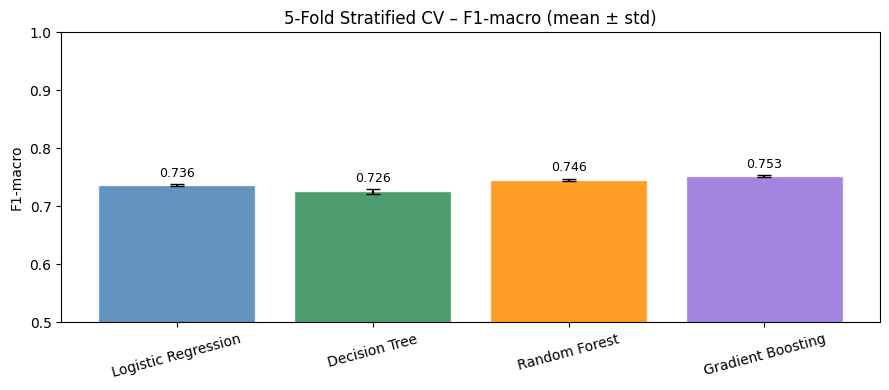

In [40]:
# Visualise CV F1-macro mean with error bars (std)
fig, ax = plt.subplots(figsize=(9, 4))
means = cv_results_df['CV F1-macro (mean)']
stds = cv_results_df['CV F1-macro (std)']
bars = ax.bar(
    means.index, means.values, yerr=stds.values,
    color=['steelblue', 'seagreen', 'darkorange', 'mediumpurple'],
    alpha=0.85, capsize=5, edgecolor='white'
)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_ylabel('F1-macro')
ax.set_title('5-Fold Stratified CV – F1-macro (mean ± std)')
ax.set_ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
## 10. ROC and Precision-Recall Curves
# Prefer ROC-AUC / PR-AUC alongside accuracy when classes are imbalanced


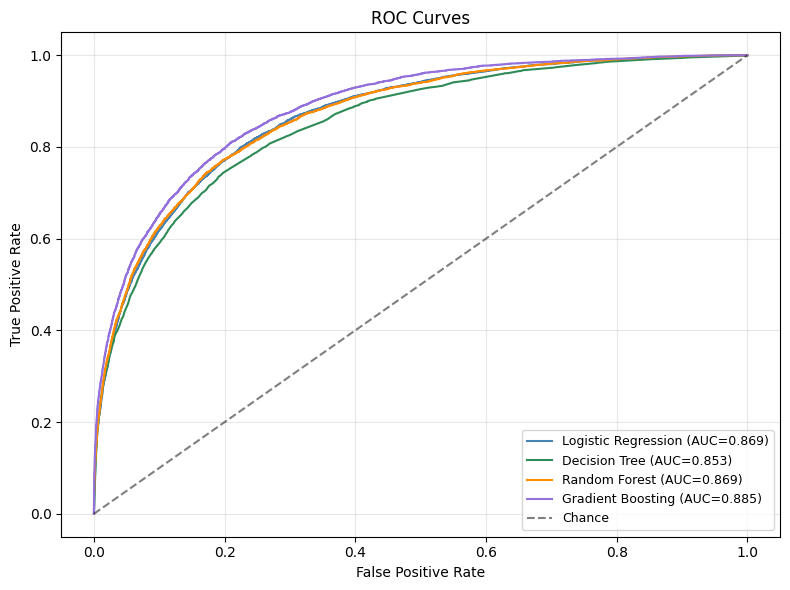

In [41]:
# Probability scores for all trained models
models_proba = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Gradient Boosting': hgb_model,
}

probas = {
    name: model.predict_proba(X_test_processed)[:, 1]
    for name, model in models_proba.items()
}

colors = {
    'Logistic Regression': 'steelblue',
    'Decision Tree': 'seagreen',
    'Random Forest': 'darkorange',
    'Gradient Boosting': 'mediumpurple',
}

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=colors[name], label=f'{name} (AUC={auc(fpr, tpr):.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

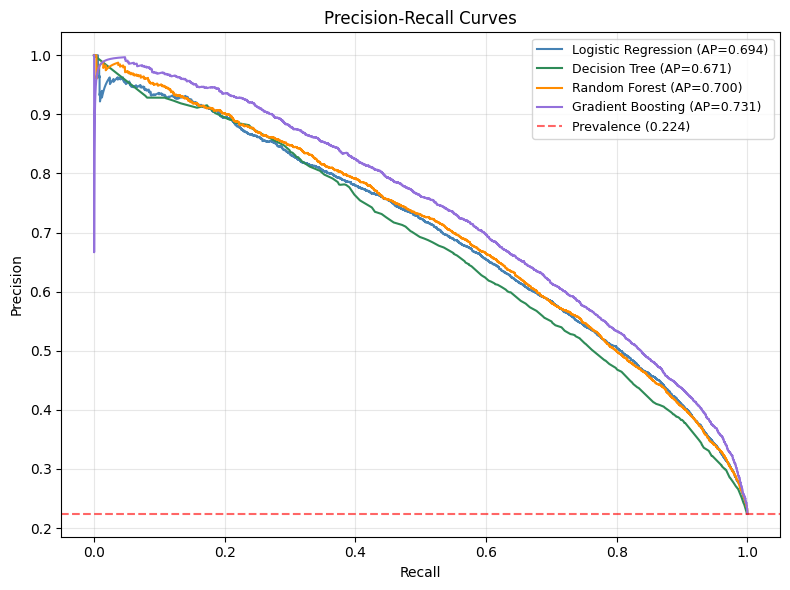

In [42]:
# Precision-Recall curves (more informative under class imbalance)
fig, ax = plt.subplots(figsize=(8, 6))
baseline_rate = y_test.mean()  # positive class prevalence

for name, proba in probas.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall, precision, color=colors[name], label=f'{name} (AP={ap:.3f})')

ax.axhline(baseline_rate, color='red', linestyle='--', alpha=0.6, label=f'Prevalence ({baseline_rate:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Logistic Regression Coefficients
# Inspect which preprocessed features push predictions toward rain vs no-rain


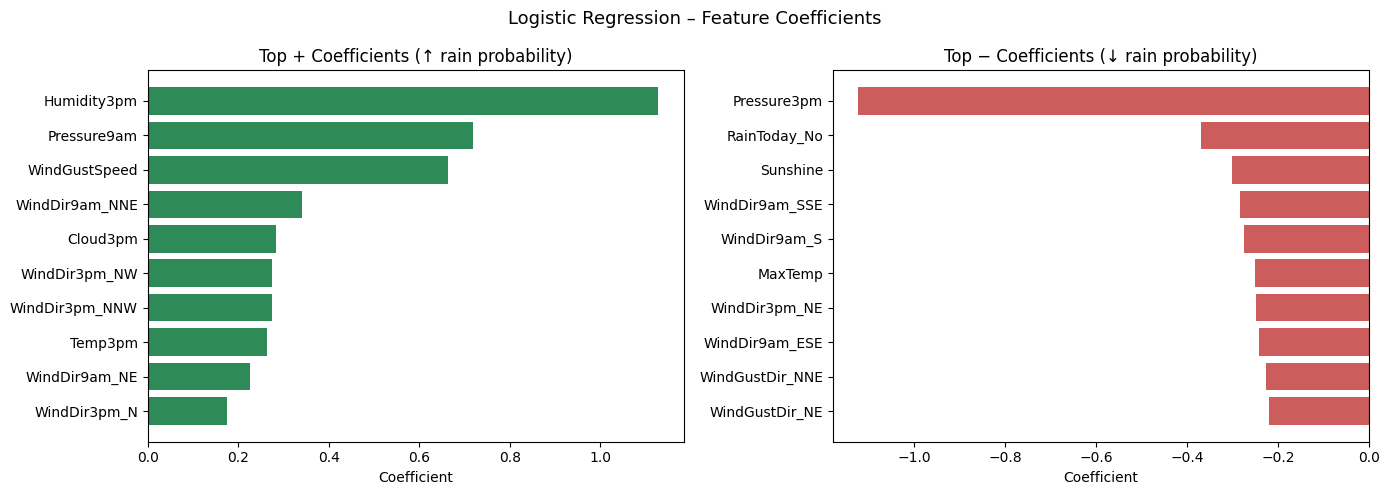

Top positive coefficients:
       Feature  Coefficient
   Humidity3pm     1.128850
   Pressure9am     0.718023
 WindGustSpeed     0.664403
WindDir9am_NNE     0.341631
      Cloud3pm     0.283479
 WindDir3pm_NW     0.274191
WindDir3pm_NNW     0.273721
       Temp3pm     0.262666
 WindDir9am_NE     0.226751
  WindDir3pm_N     0.176050

Top negative coefficients:
        Feature  Coefficient
    Pressure3pm    -1.122503
   RainToday_No    -0.368751
       Sunshine    -0.302305
 WindDir9am_SSE    -0.283809
   WindDir9am_S    -0.275398
        MaxTemp    -0.250429
  WindDir3pm_NE    -0.247763
 WindDir9am_ESE    -0.241179
WindGustDir_NNE    -0.227193
 WindGustDir_NE    -0.219311


In [43]:
# Top positive/negative coefficients from the trained Logistic Regression model
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

top_pos = coef_df.head(10)
top_neg = coef_df.tail(10).sort_values('Coefficient')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_pos['Feature'], top_pos['Coefficient'], color='seagreen')
axes[0].set_title('Top + Coefficients (↑ rain probability)')
axes[0].invert_yaxis()
axes[0].set_xlabel('Coefficient')

axes[1].barh(top_neg['Feature'], top_neg['Coefficient'], color='indianred')
axes[1].set_title('Top − Coefficients (↓ rain probability)')
axes[1].invert_yaxis()
axes[1].set_xlabel('Coefficient')

plt.suptitle('Logistic Regression – Feature Coefficients', fontsize=13)
plt.tight_layout()
plt.show()

print('Top positive coefficients:')
print(top_pos.to_string(index=False))
print()
print('Top negative coefficients:')
print(top_neg.to_string(index=False))

---
## 12. Final Model Comparison
# Compare all models using macro metrics, ROC-AUC, and the majority-class baseline


In [44]:
# Collect evaluation metrics for all models
preds = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': hgb_pred,
}

results = {}
for name, pred in preds.items():
    results[name] = {
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred, average='macro'), 4),
        'Recall': round(recall_score(y_test, pred, average='macro'), 4),
        'F1-Score': round(f1_score(y_test, pred, average='macro'), 4),
        'ROC-AUC': round(roc_auc_score(y_test, probas[name]), 4),
        'PR-AUC': round(average_precision_score(y_test, probas[name]), 4),
    }

results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
print('Model Comparison (sorted by F1-Score macro):')
print(results_df.to_string())
print()
print('Best by F1-macro:', results_df['F1-Score'].idxmax())
print('Best by ROC-AUC:', results_df['ROC-AUC'].idxmax())

Model Comparison (sorted by F1-Score macro):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Gradient Boosting      0.8029     0.7355  0.7978    0.7530   0.8847  0.7306
Random Forest          0.8005     0.7302  0.7861    0.7470   0.8694  0.7004
Logistic Regression    0.7918     0.7243  0.7856    0.7405   0.8689  0.6940
Decision Tree          0.7839     0.7146  0.7724    0.7299   0.8530  0.6707

Best by F1-macro: Gradient Boosting
Best by ROC-AUC: Gradient Boosting


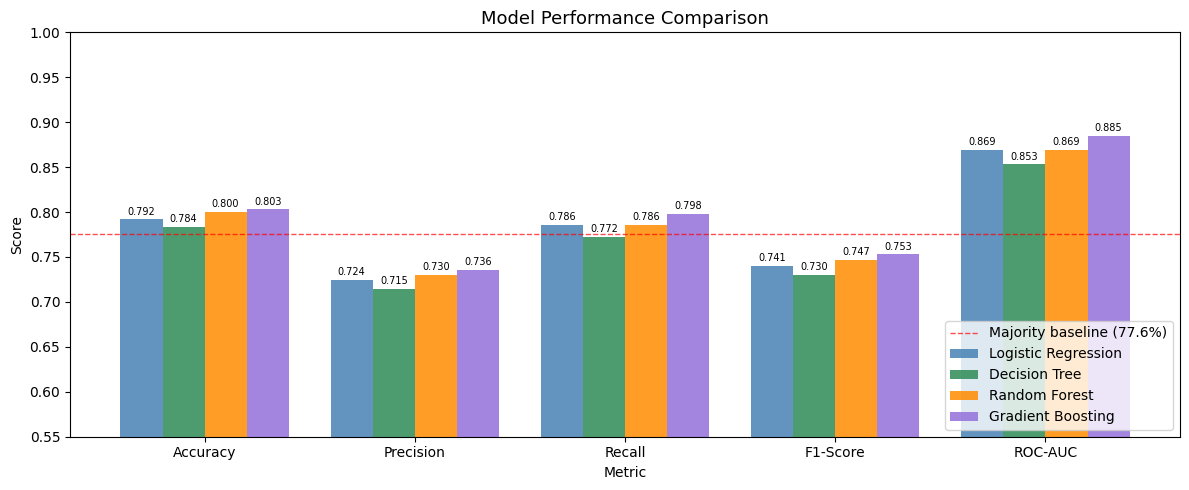

In [45]:
# Visual comparison of metrics across models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
model_names = list(results.keys())
plot_colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

for i, (model, color) in enumerate(zip(model_names, plot_colors)):
    values = [results[model][m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=model, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=7)

baseline_acc = (y_test == 0).mean()
ax.axhline(
    y=baseline_acc, color='red', linestyle='--', linewidth=1, alpha=0.7,
    label=f'Majority baseline ({baseline_acc*100:.1f}%)'
)
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.55, 1.0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 13. Conclusion
# - Class imbalance was handled with class_weight / sample_weight and evaluated with macro-F1, ROC-AUC, and PR-AUC
# - Temporal features (Month, Season, cyclical encodings) were added from Date
# - Stratified cross-validation estimated generalisation before final test comparison
# - ROC/PR curves and LR coefficients support model interpretation under imbalance
# - The best model by macro-F1 / ROC-AUC in the comparison table is recommended
